# Customer Segmentation Analysis (RFM + K-Means)
### OIBSIP Data Analytics Internship — Level 1, Task 2

**Author:** Vineet Pandey

**Objective:** Segment customers into distinct groups based on purchasing behaviour using RFM analysis
(Recency, Frequency, Monetary) and K-Means clustering, so that each group can be targeted with a suitable marketing strategy.

**Dataset:** Superstore Sales dataset (9,800 order lines, 793 customers, 2015–2018).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)


## 1. Load Data & Inspect Structure

In [2]:
df = pd.read_csv("superstore.csv", encoding="latin1")
print("Shape:", df.shape)
nulls = df.isnull().sum()
print("\nColumns with null values:\n", nulls[nulls > 0])
print("\nDuplicate rows:", df.duplicated().sum())
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True)
print("\nDate range:", df['Order_Date'].min().date(), "to", df['Order_Date'].max().date())
df.head()


Shape: (9800, 18)

Columns with null values:
 Postal_Code    11
dtype: int64

Duplicate rows: 0

Date range: 2015-01-03 to 2018-12-30


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


**Observation:** Only `Postal_Code` has missing values (11 rows, all Burlington, Vermont). It is not used in
segmentation, so no imputation is needed. There are no duplicate rows. Dates were parsed as `DD/MM/YYYY`.

## 2. Descriptive Statistics (Customer Level)

In [3]:
# One row per customer: number of orders (frequency), total spend (monetary / lifetime value), average order value
order_level = df.groupby(['Customer_ID', 'Order_ID']).agg(Order_Value=('Sales', 'sum'),
                                                         Order_Date=('Order_Date', 'max')).reset_index()

cust = order_level.groupby('Customer_ID').agg(
    Frequency=('Order_ID', 'nunique'),
    Monetary=('Order_Value', 'sum'),
    Avg_Purchase_Value=('Order_Value', 'mean'),
    Last_Purchase=('Order_Date', 'max')
).reset_index()

print("Customers:", len(cust))
cust[['Frequency', 'Monetary', 'Avg_Purchase_Value']].describe().round(2)


Customers: 793


,Frequency,Monetary,Avg_Purchase_Value
count,793.00,793.00,793.00
mean,6.21,2851.87,459.57
std,2.53,2620.67,435.09
min,1.00,4.83,2.42
25%,4.00,1081.47,210.88
50%,6.00,2215.00,361.66
75%,8.00,3670.26,560.34
max,17.00,25043.05,5008.61


In [4]:
print("Average purchase (order) value : ${:.2f}".format(order_level['Order_Value'].mean()))
print("Average purchase frequency      : {:.2f} orders per customer".format(cust['Frequency'].mean()))
print("Average customer lifetime value : ${:.2f} (total spend per customer)".format(cust['Monetary'].mean()))


Average purchase (order) value : $459.48
Average purchase frequency      : 6.21 orders per customer
Average customer lifetime value : $2851.87 (total spend per customer)


**Note on Customer Lifetime Value (CLV):** this dataset has no profit or margin column, so CLV is approximated as a
customer's **total historical spend over the 4 years**. This is the same as the Monetary value in RFM.

**Observation:** The average customer places about 6 orders, with an average order value of roughly $459, giving a
lifetime spend of about $2,850 per customer.

## 3. Feature Selection — RFM Analysis

We use three behavioural features:
- **Recency:** days since the customer's last purchase (lower = more recently active)
- **Frequency:** number of distinct orders placed
- **Monetary:** total amount spent

The snapshot date is one day after the last order in the dataset.

In [5]:
snapshot_date = df['Order_Date'].max() + pd.Timedelta(days=1)
cust['Recency'] = (snapshot_date - cust['Last_Purchase']).dt.days
rfm = cust[['Customer_ID', 'Recency', 'Frequency', 'Monetary']].copy()
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)


,Recency,Frequency,Monetary
count,793.00,793.00,793.00
mean,149.29,6.21,2851.87
std,187.08,2.53,2620.67
min,1.00,1.00,4.83
25%,31.00,4.00,1081.47
50%,76.00,6.00,2215.00
75%,185.00,8.00,3670.26
max,1166.00,17.00,25043.05


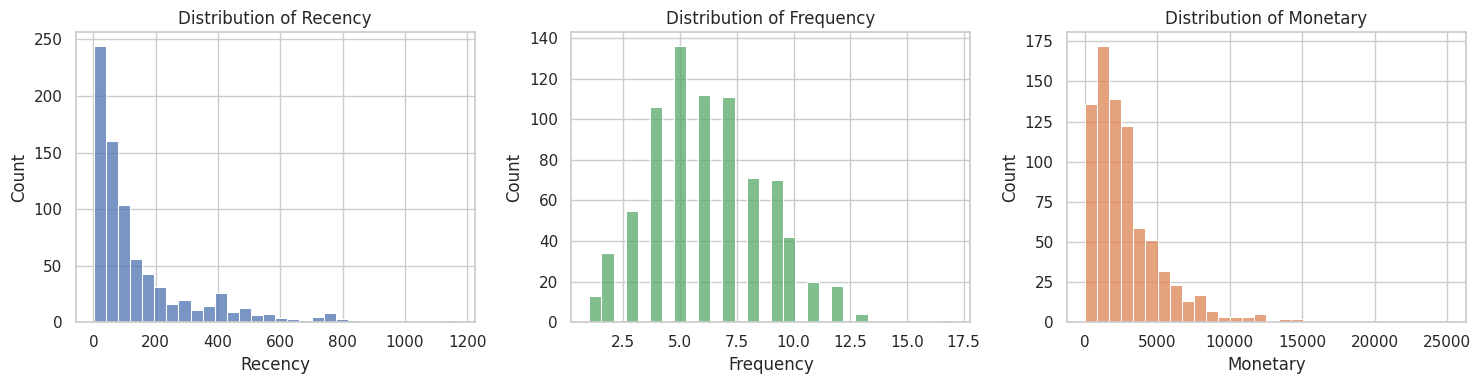

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'], ['#4C72B0', '#55A868', '#DD8452']):
    sns.histplot(rfm[col], bins=30, ax=ax, color=color)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


**Observation:** Recency and Monetary are right-skewed. For Recency the median is about 76 days against a mean of
about 149, and for Monetary the median is about $2,215 against a mean of about $2,852. Most customers are fairly recent and
spend a moderate amount, while a small group of long-inactive customers and a small group of big spenders pull the
averages up. Frequency is more balanced, with the middle half of customers placing between 4 and 8 orders.

## 4. Data Standardisation

In [7]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
print("Scaled mean (approx 0):", rfm_scaled.mean(axis=0).round(3))
print("Scaled std  (approx 1):", rfm_scaled.std(axis=0).round(3))


Scaled mean (approx 0): [ 0.  0. -0.]
Scaled std  (approx 1): [1. 1. 1.]


K-Means uses distances, so features on bigger scales (like Monetary in dollars) would dominate. `StandardScaler`
puts all three on the same scale (mean 0, standard deviation 1).

## 5. K-Means Clustering — Elbow Method

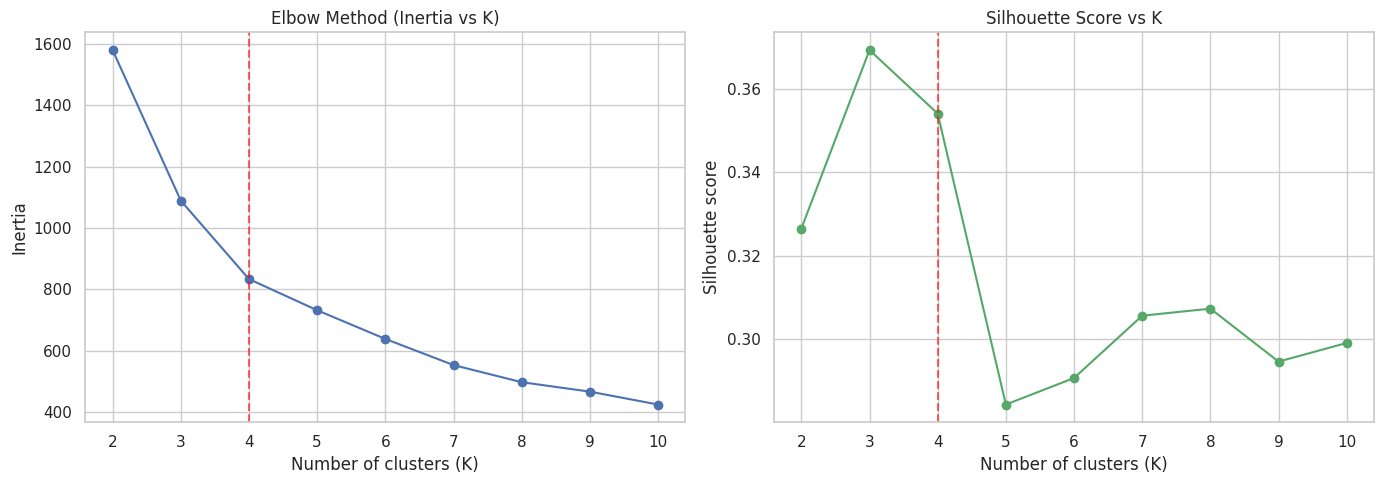

,K,Inertia,Silhouette
0,2,1580.1,0.327
1,3,1089.0,0.369
2,4,833.5,0.354
3,5,731.9,0.284
4,6,638.3,0.291
5,7,553.1,0.306
6,8,497.3,0.307
7,9,466.5,0.295
8,10,424.5,0.299


In [8]:
inertia, sil = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertia, marker='o', color="#4C72B0")
axes[0].axvline(4, color='red', linestyle='--', alpha=0.6)
axes[0].set_title("Elbow Method (Inertia vs K)")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia")
axes[1].plot(list(K_range), sil, marker='o', color="#55A868")
axes[1].axvline(4, color='red', linestyle='--', alpha=0.6)
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.show()

pd.DataFrame({'K': list(K_range), 'Inertia': np.round(inertia, 1), 'Silhouette': np.round(sil, 3)})


**Observation:** The elbow curve flattens after about **K = 4**, so adding more clusters brings smaller gains. The
silhouette score is highest at K = 3 (about 0.37), with K = 4 close behind (about 0.35). We choose **K = 4** because it
only slightly lowers cluster separation but splits out an extra, very valuable group of top spenders that K = 3 would hide
inside a bigger cluster. That extra segment is useful for marketing, and four segments are still easy to interpret.

In [9]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
print("Silhouette score for K=4:", round(silhouette_score(rfm_scaled, rfm['Cluster']), 3))
rfm['Cluster'].value_counts().sort_index()


Silhouette score for K=4: 0.354


Cluster
0    279
1     99
2    347
3     68
Name: count, dtype: int64

## 6. Cluster Visualisation

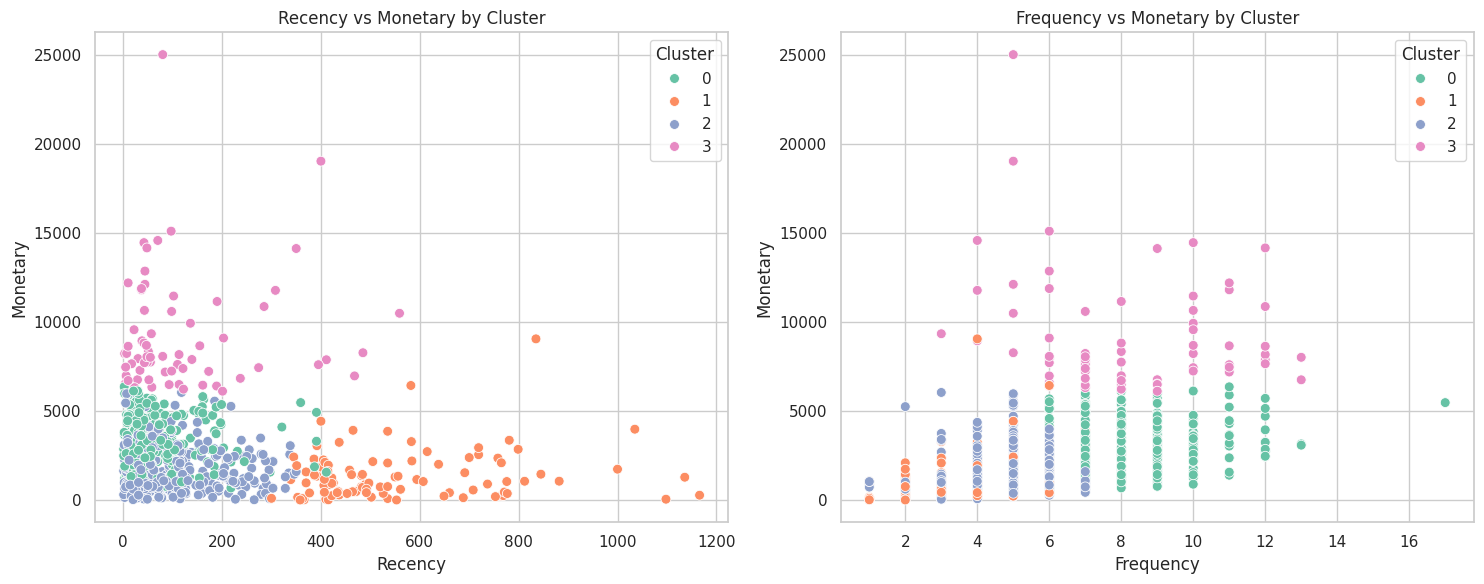

In [10]:
palette = sns.color_palette("Set2", K)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette=palette, ax=axes[0], s=50)
axes[0].set_title("Recency vs Monetary by Cluster")

sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette=palette, ax=axes[1], s=50)
axes[1].set_title("Frequency vs Monetary by Cluster")

plt.tight_layout()
plt.show()


**Observation:** In the left chart, one cluster sits far to the right: these customers have not bought for a long time.
In both charts, one small cluster sits at the top with much higher spending than everyone else. The remaining two clusters
overlap more, mainly differing in how often they order and how much they spend.

## 7. Cluster Profiling

In [11]:
profile = rfm.groupby('Cluster').agg(
    Customers=('Customer_ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(1)
profile


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,279,71.1,8.5,3226.8
1,99,556.3,3.6,1403.9
2,347,101.6,4.7,1712.4
3,68,120.7,8.2,9236.5


In [12]:
# Name each segment using simple, explicit rules on the cluster averages
lapsed  = profile['Avg_Recency'].idxmax()                       # longest time since last purchase
vip     = profile['Avg_Monetary'].idxmax()                      # highest total spend
remaining = [c for c in profile.index if c not in (lapsed, vip)]
loyal   = profile.loc[remaining, 'Avg_Frequency'].idxmax()      # most frequent of the rest
regular = [c for c in remaining if c != loyal][0]

names = {vip: 'Big Spenders (VIP)', loyal: 'Loyal Active', regular: 'Regular / Potential', lapsed: 'At Risk / Lapsed'}
profile['Segment'] = profile.index.map(names)
rfm['Segment'] = rfm['Cluster'].map(names)
profile


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Segment
Cluster,,,,,
0,279,71.1,8.5,3226.8,Loyal Active
1,99,556.3,3.6,1403.9,At Risk / Lapsed
2,347,101.6,4.7,1712.4,Regular / Potential
3,68,120.7,8.2,9236.5,Big Spenders (VIP)


**Segment descriptions (from the profile table above):**
- **Big Spenders (VIP):** a small group with by far the highest total spend, and also high order frequency.
- **Loyal Active:** the most recently active customers, ordering often, with solid but not top spending.
- **Regular / Potential:** moderately recent, with fewer orders and lower spend, so there is room to grow.
- **At Risk / Lapsed:** have not purchased for a long time, with the fewest orders and lowest spend.

## 8. Customers per Cluster

/tmp/ipykernel_143/2740558480.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg_counts.index, y=seg_counts.values, palette="Set2")


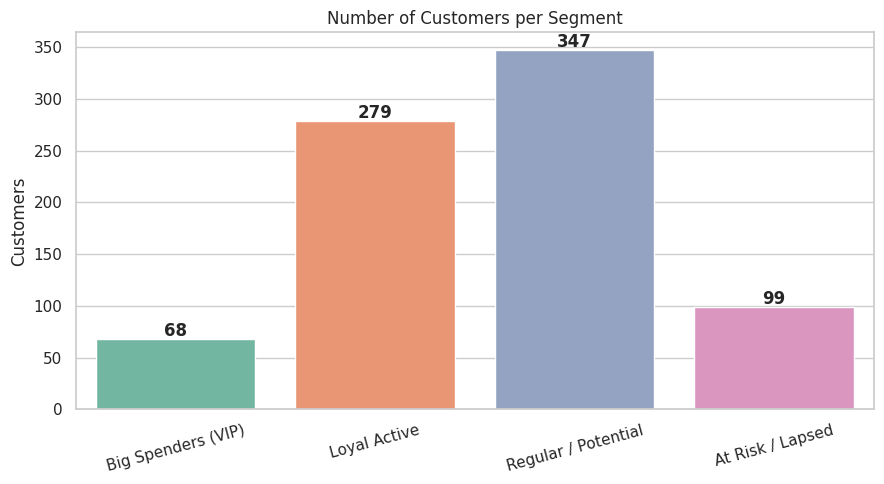

In [13]:
order_ = ['Big Spenders (VIP)', 'Loyal Active', 'Regular / Potential', 'At Risk / Lapsed']
seg_counts = rfm['Segment'].value_counts().reindex(order_)
plt.figure(figsize=(9, 5))
sns.barplot(x=seg_counts.index, y=seg_counts.values, palette="Set2")
for i, v in enumerate(seg_counts.values):
    plt.text(i, v + 3, str(v), ha='center', fontweight='bold')
plt.title("Number of Customers per Segment")
plt.ylabel("Customers")
plt.xlabel("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


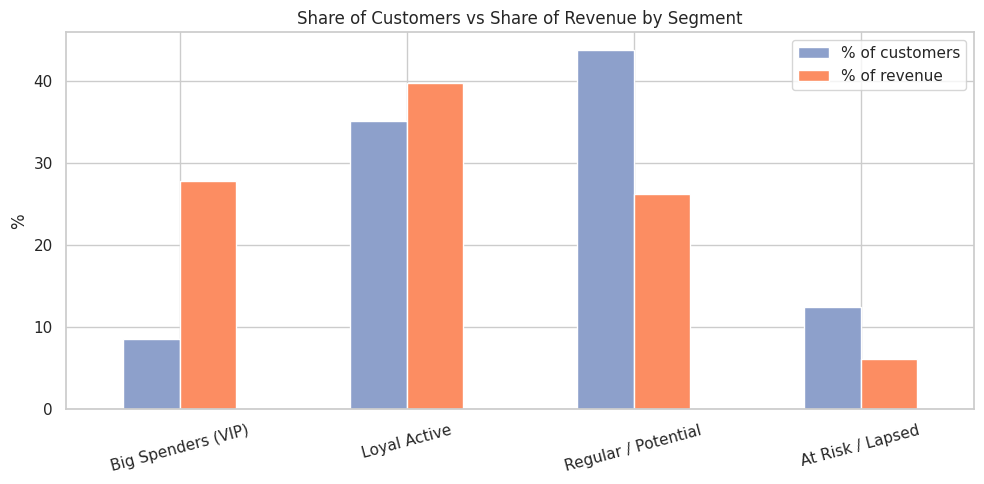

,% of customers,% of revenue
Segment,,
Big Spenders (VIP),8.6,27.8
Loyal Active,35.2,39.8
Regular / Potential,43.8,26.3
At Risk / Lapsed,12.5,6.1


In [14]:
rev = rfm.groupby('Segment')['Monetary'].sum().reindex(order_)
share = (rev / rev.sum() * 100).round(1)
cust_share = (seg_counts / seg_counts.sum() * 100).round(1)

compare = pd.DataFrame({'% of customers': cust_share, '% of revenue': share})
compare.plot(kind='bar', figsize=(10, 5), color=['#8DA0CB', '#FC8D62'])
plt.title("Share of Customers vs Share of Revenue by Segment")
plt.ylabel("%")
plt.xlabel("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
compare


**Observation:** Compare the two bars for each segment. The Big Spenders (VIP) segment is a small share of customers but
contributes a much larger share of revenue, which shows how much the business depends on a few customers. The At Risk / Lapsed
segment is the reverse: a bigger share of customers than of revenue.

## 9. Insights & Marketing Recommendations

| Segment | Who they are | Recommended marketing action |
|---|---|---|
| **Big Spenders (VIP)** | Few customers, highest spend | Treat as top priority: dedicated account care, early access to new products, premium bundles and thank-you offers. Losing even a few of these hurts revenue most. |
| **Loyal Active** | Recent and frequent buyers | Run a loyalty programme, cross-sell related categories and offer bundle deals to lift order value and move some into the VIP group. |
| **Regular / Potential** | Moderately active, lower spend | Send personalised recommendations and limited-time offers to increase purchase frequency and basket size. |
| **At Risk / Lapsed** | Long time since last purchase | Run a win-back campaign with a discount code and a "we miss you" email, and send a short survey to learn why they stopped buying. |

**Overall takeaway:** treat segments differently. Protect the top segment, grow the middle ones, and re-engage the lapsed group
before they are lost for good.
